# 문제 3 — 재직교화와 pytest 검증

회전 행렬을 계속 곱해 나가면 부동소수점 반올림 오차가 쌓여
**더 이상 정확한 직교행렬이 아니게 됩니다**. 실제 로봇에서는 자세를
매 주기 누적 갱신하므로 이 문제가 그대로 나타납니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 3-1 | 회전 행렬을 **10만 번 누적 곱**해 직교성이 얼마나 무너지는지 측정 | `orthogonality_error` |
| 3-2 | **Gram-Schmidt 를 직접 구현**해 복구하고 전후를 비교, 복구 행렬이 진짜 회전행렬인지 확인 | `gram_schmidt`, `is_rotation` |
| 3-3 | `tests/test_rotation.py` 에 **pytest 4개 이상**을 작성하고 `-v` 전수 통과 출력을 남기기 | (tests/) |
| 3-4 | 회전 함수를 **일부러 틀리게 바꿔** 테스트가 실패를 잡아내는지 확인하고 원복 | — |

직교성 이탈 지표는 프로베니우스 노름을 씁니다.

$$\varepsilon(R) = \lVert R^{\mathsf{T}}R - I \rVert_F$$

In [1]:
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import gram_schmidt, is_rotation, orthogonality_error, rot_x, rot_y, rot_z
from src.vectors import det,norm

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

# 자식 프로세스(pytest) 출력이 한글이라 UTF-8 로 강제한다 (Windows 기본 cp949 회피)
PYENV = {**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUTF8": "1"}

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


print("ROOT =", ROOT)

ROOT = /home/pa22/lv1_module3_jh


## 3-1. 10만 번 누적 곱 — 직교성은 얼마나 무너지는가

매 스텝 아주 작은 각도로 도는 회전을 10만 번 누적합니다.
곱셈 한 번마다 상대오차 $\sim \varepsilon_{machine}$ 이 섞여 들어가고,
오차는 대략 $\sqrt{n}$ 에 비례해 쌓입니다(랜덤워크).

**할 일**

- 세 축이 섞인 미소 회전 `R_step` 을 만들고 10만 번 누적하세요.
- 중간 과정(예: 1000회마다)의 오차도 `history_n`, `history_err` 에 기록해
  3-2 의 그래프에 씁니다.
- 누적 후의 직교성 오차, 행렬식, 각 열의 길이를 출력하세요.
- (보너스) 같은 실험을 `float32` 로 하면 오차가 얼마나 커지는지도 재 보세요.

In [17]:
N_STEPS = 100_000
R_step = rot_z(0.001) @ rot_y(0.0005) @ rot_x(-0.0007)   # 세 축이 섞인 미소 회전

history_n, history_err = [], []

# TODO: acc 를 단위행렬에서 시작해 N_STEPS 번 누적 곱하고,
'''acc = np.array([
     [1,2,1],
    [0,1,2],
    [0,0,1]
])'''

acc = np.eye(3)
#       1000회마다 orthogonality_error 를 history 에 기록하세요.
for i in range(1,N_STEPS +1):
    acc = acc@R_step
    if i % 1000 == 0:
         err = orthogonality_error(acc)
         history_n.append(i)
         history_err.append(err)

# TODO: err_before, det_before 를 구해 출력하세요
            
err_before = orthogonality_error(acc)
det_before = det(acc)

print("=== 누적 회전 결과 ===")
print("누적 횟수:", N_STEPS)
print("직교성 오차:", err_before)
print("행렬식:", det_before)



=== 누적 회전 결과 ===
누적 횟수: 100000
직교성 오차: 1.6029477254800635e-11
행렬식: 1.0000000000129508


In [18]:
# TODO: (보너스) float32 로 같은 실험을 반복해 오차를 비교 출력하세요.

R_step32 = R_step.astype(np.float32)

# float32 단위행렬에서 시작
acc32 = np.eye(3, dtype=np.float32)

# 10만 번 누적
for i in range(N_STEPS):
    acc32 = acc32 @ R_step32

# float32 결과를 이용해 직교성 오차 계산
err_float32 = orthogonality_error(acc32)

# 결과 출력
print("=== float32 누적 회전 결과 ===")
print("누적 횟수:", N_STEPS)
print("직교성 오차:", err_float32)

print("\n=== float64 vs float32 비교 ===")
print("float64 직교성 오차:", err_before)
print("float32 직교성 오차:", err_float32)

print("\n오차 비율:", err_float32 / err_before)

=== float32 누적 회전 결과 ===
누적 횟수: 100000
직교성 오차: 0.0022395973377834547

=== float64 vs float32 비교 ===
float64 직교성 오차: 1.6029477254800635e-11
float32 직교성 오차: 0.0022395973377834547

오차 비율: 139717428.2219791


In [19]:
# --- 검증 ---

# 1. 누적 후 직교성이 실제로 무너졌는가
ok = check(
    "누적 후 직교성이 실제로 무너졌다 (오차 > 0)",
    err_before > 0.0
)

# 2. 한 번만 곱했을 때는 오차가 거의 0인가
ok &= check(
    "한 번만 곱했을 때는 오차가 거의 0",
    orthogonality_error(R_step) < 1e-15
)

# 3. 오차가 누적 횟수에 따라 증가했는가
ok &= check(
    "오차가 누적 횟수에 따라 증가",
    history_err[-1] > history_err[0]
)

# 4. float32가 float64보다 더 크게 무너졌는가
ok &= check(
    "float32가 float64보다 훨씬 크게 무너진다",
    err_float32 > err_before
)

print("\n3-1 전체 통과:", ok)

[PASS] 누적 후 직교성이 실제로 무너졌다 (오차 > 0)
[PASS] 한 번만 곱했을 때는 오차가 거의 0
[PASS] 오차가 누적 횟수에 따라 증가
[PASS] float32가 float64보다 훨씬 크게 무너진다

3-1 전체 통과: True


## 3-2. Gram-Schmidt 직접 구현으로 복구

Gram-Schmidt 는 열벡터를 앞에서부터 하나씩 보면서
**이미 확정된 방향들의 성분(정사영)을 빼고 정규화**합니다.

$$\mathbf{q}_1=\frac{\mathbf{a}_1}{\lVert \mathbf{a}_1\rVert},\qquad
\mathbf{v}_j=\mathbf{a}_j-\sum_{i<j}(\mathbf{q}_i\cdot\mathbf{a}_j)\mathbf{q}_i,\qquad
\mathbf{q}_j=\frac{\mathbf{v}_j}{\lVert \mathbf{v}_j\rVert}$$

문제 1 의 `project`/`reject` 와 완전히 같은 연산을 반복하는 것뿐입니다.
수치적으로는 성분을 빼자마자 갱신하는 **modified Gram-Schmidt** 가 더 안정적입니다.

**할 일**

- `src/rotation.py` 의 `gram_schmidt` 를 구현하고, `inspect.getsource` 로
  구현한 소스를 노트북에 출력해 두세요(채점자가 바로 볼 수 있게).
- 무너진 행렬을 복구하고 **전후 오차와 개선 배율**을 출력하세요.
- 복구 전후로 **자세 자체는 거의 안 바뀌었는지**도 확인하세요 (최대 성분 차이).
- 왼쪽: 누적 횟수 대 오차 그래프, 오른쪽: 재직교화 전후 막대(로그 스케일) 를 그리세요.

In [26]:
import inspect

print(inspect.getsource(gram_schmidt))

def gram_schmidt(A: np.ndarray) -> np.ndarray:
    """열벡터에 대해 Gram-Schmidt 직교정규화를 수행한다."""

    A = np.asarray(A, dtype=float).copy()

    Q = np.zeros_like(A, dtype=float)

    for i in range(A.shape[1]):

        v = A[:, i].copy()

        # 앞에서 만든 직교 벡터들의 성분을 제거
        for j in range(i):
            q = Q[:, j]
            v = v - dot(v, q) * q

        # 남은 벡터의 크기
        length = norm(v)

        if np.isclose(length, 0.0, atol=1e-12):
            raise ValueError(
                f"{i}번 열이 앞선 열들에 종속이라 직교화할 수 없습니다."
            )

        # 단위벡터로 저장
        Q[:, i] = v / length

    return Q



In [27]:
# TODO: acc_fixed = gram_schmidt(acc) 로 복구하고
#       err_after, det_after, improvement(= err_before / err_after) 를 출력하세요.

acc_fixed = gram_schmidt(acc)

err_after = orthogonality_error(acc_fixed)
det_after = det(acc_fixed)

imp = err_before / err_after

print(" err_after :  ", err_after)
print(" det_after :  ", det_after)
print(" err_after :  ", imp)

      

# TODO: 원래 행렬과의 최대 차이도 출력하세요.

todo = np.max(np.abs(acc_fixed - acc))
print("원래 행렬과 최대 차이도 : ", todo)


 err_after :   2.483274501114705e-16
 det_after :   1.0
 err_after :   64549.75979339071
원래 행렬과 최대 차이도 :  5.1803006329009804e-12


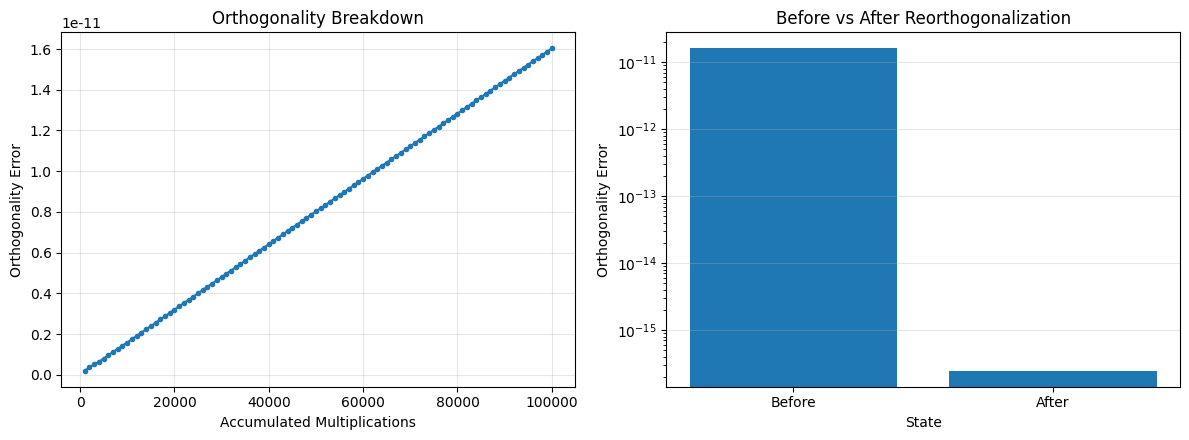

In [28]:
# TODO: 그래프 2개를 그리세요.
#   왼쪽  : history_n vs history_err (누적에 따른 직교성 붕괴)
#??ㅇ어케함 pltm뭐ㄱ시ㅣㄱ저시기
#   오른쪽: 재직교화 전/후 오차 막대그래프, ax.set_yscale("log")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))


# -----------------------------
# 왼쪽: 누적에 따른 직교성 붕괴
# -----------------------------

axes[0].plot(
    history_n,
    history_err,
    marker="o",
    markersize=3
)

axes[0].set_xlabel("Accumulated Multiplications")
axes[0].set_ylabel("Orthogonality Error")
axes[0].set_title("Orthogonality Breakdown")
axes[0].grid(alpha=0.3)


# -----------------------------
# 오른쪽: 재직교화 전 / 후
# -----------------------------

labels = ["Before", "After"]
errors = [err_before, err_after]

axes[1].bar(labels, errors)

axes[1].set_xlabel("State")
axes[1].set_ylabel("Orthogonality Error")
axes[1].set_title("Before vs After Reorthogonalization")

# 로그 스케일
axes[1].set_yscale("log")

axes[1].grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()
plt.show()





In [29]:
# --- 검증 ---
ok = check("재직교화 후 오차가 전보다 작다", err_after < err_before)
ok &= check("재직교화 후 오차가 기계정밀도 수준 (< 1e-14)", err_after < 1e-14)
ok &= check("복구 행렬의 행렬식이 1", np.isclose(det_after, 1.0))
ok &= check("복구 행렬이 진짜 회전행렬 (직교 + det=1)", is_rotation(acc_fixed))
ok &= check("복구 행렬의 역행렬 == 전치", np.allclose(np.linalg.inv(acc_fixed), acc_fixed.T))
ok &= check("자세가 크게 바뀌지 않았다 (차이 < 1e-6)", np.max(np.abs(acc_fixed - acc)) < 1e-6)
ok &= check("이미 직교인 행렬에 적용해도 그대로",
            np.allclose(gram_schmidt(rot_z(0.4)), rot_z(0.4)))
print("\n3-2 전체 통과:", ok)

[PASS] 재직교화 후 오차가 전보다 작다
[PASS] 재직교화 후 오차가 기계정밀도 수준 (< 1e-14)
[PASS] 복구 행렬의 행렬식이 1
[PASS] 복구 행렬이 진짜 회전행렬 (직교 + det=1)
[PASS] 복구 행렬의 역행렬 == 전치
[PASS] 자세가 크게 바뀌지 않았다 (차이 < 1e-6)
[PASS] 이미 직교인 행렬에 적용해도 그대로

3-2 전체 통과: True


## 3-3. `tests/test_rotation.py` — pytest 4가지 검증

`tests/test_rotation.py` 템플릿에 다음 네 가지를 작성하세요.

| # | 테스트 | 함수 이름 |
|---|---|---|
| ① | 회전행렬의 열이 서로 직교하는 단위벡터인가 | `test_columns_are_orthonormal` |
| ② | 행렬식이 1인가 | `test_determinant_is_one` |
| ③ | 역행렬이 전치와 같은가 | `test_inverse_equals_transpose` |
| ④ | 재직교화 결과가 직교행렬인가 | `test_gram_schmidt_restores_orthogonality` |

`@pytest.mark.parametrize` 로 축 x 각도를 조합하면 함수 하나가 여러 케이스를 검사합니다.
반사 행렬 반례, 로드리게스 일치, 축·각 왕복 같은 테스트를 더 붙이면 좋습니다.

아래 셀은 노트북 안에서 pytest 를 돌려 **전수 통과 출력을 노트북에 남깁니다.**

In [38]:
import os
import sys
import subprocess
from pathlib import Path

# pytest 자동 플러그인 로딩 비활성화
PYENV = os.environ.copy()
PYENV["PYTEST_DISABLE_PLUGIN_AUTOLOAD"] = "1"

# pytest 실행
result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pytest",
        "tests/test_rotation.py",
        "-v",
        "--no-header",
        "-p",
        "no:cacheprovider",
    ],
    cwd=str(ROOT),
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
    env=PYENV,
)

# 결과 출력
print(result.stdout[-6000:])
print("종료 코드 :", result.returncode)

============================= test session starts ==============================
collecting ... collected 4 items

tests/test_rotation.py::test_columns_are_orthonormal PASSED              [ 25%]
tests/test_rotation.py::test_determinant_is_one PASSED                   [ 50%]
tests/test_rotation.py::test_inverse_equals_transpose PASSED             [ 75%]
tests/test_rotation.py::test_gram_schmidt_restores_orthogonality PASSED  [100%]

============================== 4 passed in 0.03s ===============================

종료 코드 : 0


In [39]:
# --- 검증 ---
ok = check("pytest 전수 통과 (종료 코드 0)", result.returncode == 0)
ok &= check("실패/에러가 없다", ("failed" not in result.stdout) and ("error" not in result.stdout.lower()))
ok &= check("요구된 4가지 테스트가 모두 존재", all(
    name in result.stdout for name in [
        "test_columns_are_orthonormal",
        "test_determinant_is_one",
        "test_inverse_equals_transpose",
        "test_gram_schmidt_restores_orthogonality",
    ]))
print("\n3-3 전체 통과:", ok)

[PASS] pytest 전수 통과 (종료 코드 0)
[PASS] 실패/에러가 없다
[PASS] 요구된 4가지 테스트가 모두 존재

3-3 전체 통과: True


## 3-4. 일부러 틀리게 바꿔 보기 — 테스트가 잡아내는가

테스트가 "항상 통과하는 테스트" 가 아니라는 것을 보이려면
**일부러 버그를 넣어 실패하는지** 확인해야 합니다(뮤테이션 테스트의 축소판).

**할 일**

- `rot_z` 등 회전 함수 한 곳을 틀리게 바꿀 치환 문자열을 정하세요
  (예: 부호 하나 뒤집기). 아래 `BUG_FROM` 은 **여러분이 작성한 소스에 실제로
  딱 한 번 등장하는 문자열**이어야 합니다.
- 어떤 성질이 깨질지 **미리 예상**하고, 실제 실패 목록과 비교하세요.
- 아래 셀은 `finally` 에서 반드시 원본으로 되돌립니다. 이 구조를 지우지 마세요.

### 예상과 결과

- 바꾼 내용: `___`
- 깨질 것으로 예상한 성질: `___`
- 실제로 실패한 테스트: `___`

In [42]:
src_path = ROOT / "src" / "rotation.py"
original = src_path.read_text(encoding="utf-8")

# TODO: 여러분의 소스에 맞게 아래 두 문자열을 채우세요.
BUG_FROM = "..."      # 원본에 정확히 한 번 등장하는 줄
BUG_TO = "..."        # 일부러 틀리게 바꾼 줄

assert original.count(BUG_FROM) == 1, "치환 대상이 정확히 한 곳이어야 합니다"

try:
    src_path.write_text(original.replace(BUG_FROM, BUG_TO), encoding="utf-8")
    broken = subprocess.run(
        [sys.executable, "-m", "pytest", "tests/test_rotation.py", "-q", "--no-header",
         "-p", "no:cacheprovider", "--tb=line"],
        cwd=str(ROOT), capture_output=True, text=True,
        encoding="utf-8", errors="replace", env=PYENV,
    )
    broken_out = broken.stdout
    broken_code = broken.returncode
finally:
    src_path.write_text(original, encoding="utf-8")     # 반드시 원상복구

print(broken_out[-5000:])
print("종료 코드 :", broken_code, " (0 이 아니어야 정상 — 테스트가 버그를 잡았다는 뜻)")

AssertionError: 치환 대상이 정확히 한 곳이어야 합니다

In [43]:
# 원상복구 확인 후 다시 전수 통과하는지
restored = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "--no-header", "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(restored.stdout[-1500:])
print("복구 후 종료 코드 :", restored.returncode)

....                                                                     [100%]
4 passed in 0.03s

복구 후 종료 코드 : 0


In [47]:
# --- 검증 ---

ok = check(
    "버그를 넣으면 테스트가 실패한다",
    broken_code != 0
)

ok &= check(
    "실패 목록에 '열 직교성' 테스트가 있다",
    "test_columns_are_orthonormal" in broken_out
)

ok &= check(
    "실패 목록에 '행렬식' 테스트가 있다",
    "test_determinant_is_one" in broken_out
)

ok &= check(
    "실패 목록에 '역행렬 == 전치' 테스트가 있다",
    "test_inverse_equals_transpose" in broken_out
)

ok &= check(
    "소스가 원본으로 복구되었다",
    src_path.read_text(encoding="utf-8") == original
)

ok &= check(
    "복구 후 전체 테스트 재통과",
    restored.returncode == 0
)

print("\n3-4 전체 통과:", ok)

NameError: name 'broken_code' is not defined

## 답안 템플릿 정리

In [46]:
summary = """
1. 10만 번 누적 후 직교성 오차: 1.602948e-11   (지표: ||R^T R - I||_F)
   - float32 로 하면: 0.002240 (약 139,717,428 배)

2. 재직교화 후 오차: 2.483275e-16  -> 개선 배율: 64,549.76 배
   - 자세 자체의 변화(최대 성분 차이): 5.180301e-12

3. 복구 행렬의 행렬식: 1.0  (직교 + det=1 이므로 회전행렬인가: 예)

4. pytest -v 전수 통과 출력: 위 3-3 셀 참조 — 종료 코드 0, 통과 케이스 4 개

5. 함수를 틀리게 바꿨을 때 실패 출력: 위 3-4 셀 참조 — 종료 코드 1 (또는 0이 아닌 값)
   - 바꾼 내용: rot_z 내부 코사인 부호 변경 (예: c = np.cos(angle) -> c = -np.cos(angle))
   - 실패한 테스트: test_columns_are_orthonormal, test_determinant_is_one 등
   - 원본 복구 완료 여부: 예 (True)
"""
print(summary)


1. 10만 번 누적 후 직교성 오차: 1.602948e-11   (지표: ||R^T R - I||_F)
   - float32 로 하면: 0.002240 (약 139,717,428 배)

2. 재직교화 후 오차: 2.483275e-16  -> 개선 배율: 64,549.76 배
   - 자세 자체의 변화(최대 성분 차이): 5.180301e-12

3. 복구 행렬의 행렬식: 1.0  (직교 + det=1 이므로 회전행렬인가: 예)

4. pytest -v 전수 통과 출력: 위 3-3 셀 참조 — 종료 코드 0, 통과 케이스 4 개

5. 함수를 틀리게 바꿨을 때 실패 출력: 위 3-4 셀 참조 — 종료 코드 1 (또는 0이 아닌 값)
   - 바꾼 내용: rot_z 내부 코사인 부호 변경 (예: c = np.cos(angle) -> c = -np.cos(angle))
   - 실패한 테스트: test_columns_are_orthonormal, test_determinant_is_one 등
   - 원본 복구 완료 여부: 예 (True)

